In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [4]:
df=pd.read_csv(r"C:\Users\harsh\Downloads\Sub_Division_IMD_2017.csv")
print(df)

                    SUBDIVISION  YEAR   JAN    FEB    MAR    APR    MAY  \
0     Andaman & Nicobar Islands  1901  49.2   87.1   29.2    2.3  528.8   
1     Andaman & Nicobar Islands  1902   0.0  159.8   12.2    0.0  446.1   
2     Andaman & Nicobar Islands  1903  12.7  144.0    0.0    1.0  235.1   
3     Andaman & Nicobar Islands  1904   9.4   14.7    0.0  202.4  304.5   
4     Andaman & Nicobar Islands  1905   1.3    0.0    3.3   26.9  279.5   
...                         ...   ...   ...    ...    ...    ...    ...   
4183                Lakshadweep  2013  26.2   34.4   37.5    5.3   88.3   
4184                Lakshadweep  2014  53.2   16.1    4.4   14.9   57.4   
4185                Lakshadweep  2015   2.2    0.5    3.7   87.1  133.1   
4186                Lakshadweep  2016  59.6   12.1    3.2    2.6   77.4   
4187                Lakshadweep  2017  21.3    0.9  100.2    1.8  145.7   

        JUN    JUL    AUG    SEP    OCT    NOV    DEC  ANNUAL     JF    MAM  \
0     517.5  365.1  

In [5]:
df.shape[0]

4188

In [6]:
df.shape[1]

19

In [7]:
df.head()

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
0,Andaman & Nicobar Islands,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,Andaman & Nicobar Islands,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,Andaman & Nicobar Islands,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,Andaman & Nicobar Islands,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,Andaman & Nicobar Islands,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [8]:
df.tail()

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
4183,Lakshadweep,2013,26.2,34.4,37.5,5.3,88.3,426.2,296.4,154.4,180.0,72.8,78.1,26.7,1426.3,60.6,131.1,1057.0,177.6
4184,Lakshadweep,2014,53.2,16.1,4.4,14.9,57.4,244.1,116.1,466.1,132.2,169.2,59.0,62.3,1395.0,69.3,76.7,958.5,290.5
4185,Lakshadweep,2015,2.2,0.5,3.7,87.1,133.1,296.6,257.5,146.4,160.4,165.4,231.0,159.0,1642.9,2.7,223.9,860.9,555.4
4186,Lakshadweep,2016,59.6,12.1,3.2,2.6,77.4,321.1,262.6,86.2,75.6,58.6,32.0,74.7,1065.7,71.7,83.2,745.4,165.4
4187,Lakshadweep,2017,21.3,0.9,100.2,1.8,145.7,521.9,164.2,206.2,216.0,137.1,63.5,160.1,1738.9,22.2,247.8,1108.3,360.7


In [9]:
print("\n Column names:")
print(df.columns.tolist())


 Column names:
['SUBDIVISION', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JF', 'MAM', 'JJAS', 'OND']


In [10]:
print(df.dtypes)

SUBDIVISION        str
YEAR             int64
JAN            float64
FEB            float64
MAR            float64
APR            float64
MAY            float64
JUN            float64
JUL            float64
AUG            float64
SEP            float64
OCT            float64
NOV            float64
DEC            float64
ANNUAL         float64
JF             float64
MAM            float64
JJAS           float64
OND            float64
dtype: object


In [11]:
print(df.describe())

              YEAR          JAN          FEB          MAR          APR  \
count  4188.000000  4184.000000  4185.000000  4182.000000  4184.000000   
mean   1959.220630    18.938337    21.599427    27.412912    43.071845   
std      33.717097    33.793128    35.731734    46.927963    68.150985   
min    1901.000000     0.000000     0.000000     0.000000     0.000000   
25%    1930.000000     0.600000     0.500000     1.000000     3.000000   
50%    1959.000000     5.950000     6.500000     7.900000    15.450000   
75%    1988.000000    22.000000    26.600000    31.375000    49.650000   
max    2017.000000   583.700000   403.500000   605.600000   595.100000   

               MAY          JUN          JUL          AUG          SEP  \
count  4185.000000  4183.000000  4181.000000  4184.000000  4182.000000   
mean     85.660860   230.117475   347.020043   289.742185   197.316332   
std     122.695137   234.292087   268.850702   188.426071   135.547646   
min       0.000000     0.400000     0

In [12]:
print("\n Missing Values :")
print(df.isnull().sum())


 Missing Values :
SUBDIVISION     0
YEAR            0
JAN             4
FEB             3
MAR             6
APR             4
MAY             3
JUN             5
JUL             7
AUG             4
SEP             6
OCT             7
NOV            11
DEC            10
ANNUAL         26
JF              6
MAM             9
JJAS           10
OND            13
dtype: int64


In [13]:
df.replace('NA', np.nan, inplace=True)

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
0,Andaman & Nicobar Islands,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,Andaman & Nicobar Islands,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,Andaman & Nicobar Islands,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,Andaman & Nicobar Islands,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,Andaman & Nicobar Islands,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4183,Lakshadweep,2013,26.2,34.4,37.5,5.3,88.3,426.2,296.4,154.4,180.0,72.8,78.1,26.7,1426.3,60.6,131.1,1057.0,177.6
4184,Lakshadweep,2014,53.2,16.1,4.4,14.9,57.4,244.1,116.1,466.1,132.2,169.2,59.0,62.3,1395.0,69.3,76.7,958.5,290.5
4185,Lakshadweep,2015,2.2,0.5,3.7,87.1,133.1,296.6,257.5,146.4,160.4,165.4,231.0,159.0,1642.9,2.7,223.9,860.9,555.4
4186,Lakshadweep,2016,59.6,12.1,3.2,2.6,77.4,321.1,262.6,86.2,75.6,58.6,32.0,74.7,1065.7,71.7,83.2,745.4,165.4


In [14]:
month_cols = ['JAN','FEB','MAR','APR','MAY','JUN',
              'JUL','AUG','SEP','OCT','NOV','DEC','ANNUAL']
for col in month_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [15]:
df[month_cols] = df[month_cols].fillna(df[month_cols].mean())

In [16]:
df['ANNUAL'] = df[['JAN','FEB','MAR','APR','MAY','JUN',
                    'JUL','AUG','SEP','OCT','NOV','DEC']].sum(axis=1)

In [17]:
df['SUBDIVISION'] = df['SUBDIVISION'].str.strip()

In [18]:
print(f" Missing values after cleaning: {df.isnull().sum().sum()}")
print(f" Total rows after cleaning: {len(df)}")

 Missing values after cleaning: 38
 Total rows after cleaning: 4188


In [19]:
#NEW COLUMNS
df['MONSOON'] = df[['JUN','JUL','AUG','SEP']].sum(axis=1)
df['WINTER'] = df[['DEC','JAN','FEB']].sum(axis=1)
df['SUMMER'] = df[['MAR','APR','MAY']].sum(axis=1)
df['DECADE'] = (df['YEAR'] // 10) * 10
print("New Columns: MONSOON, WINTER, SUMMER, DECADE")

New Columns: MONSOON, WINTER, SUMMER, DECADE


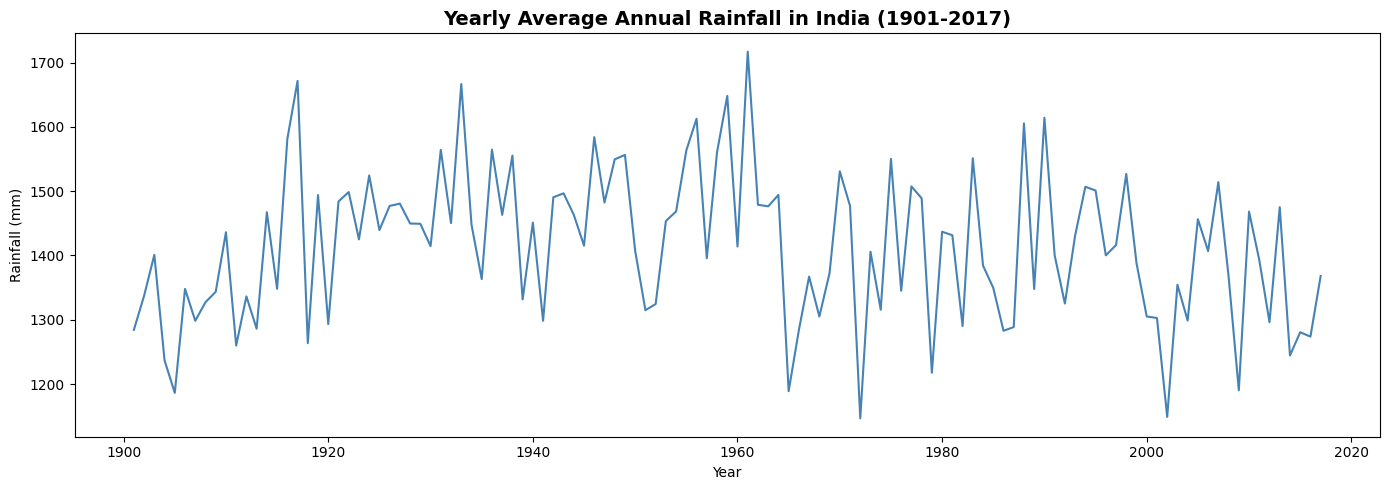

In [20]:
plt.figure(figsize=(14, 5))
yearly_avg = df.groupby('YEAR')['ANNUAL'].mean()
plt.plot(yearly_avg.index, yearly_avg.values, color='steelblue', linewidth=1.5)
plt.title('Yearly Average Annual Rainfall in India (1901-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.tight_layout()
plt.savefig('graph1_yearly_trend.png', dpi=150)
plt.show()


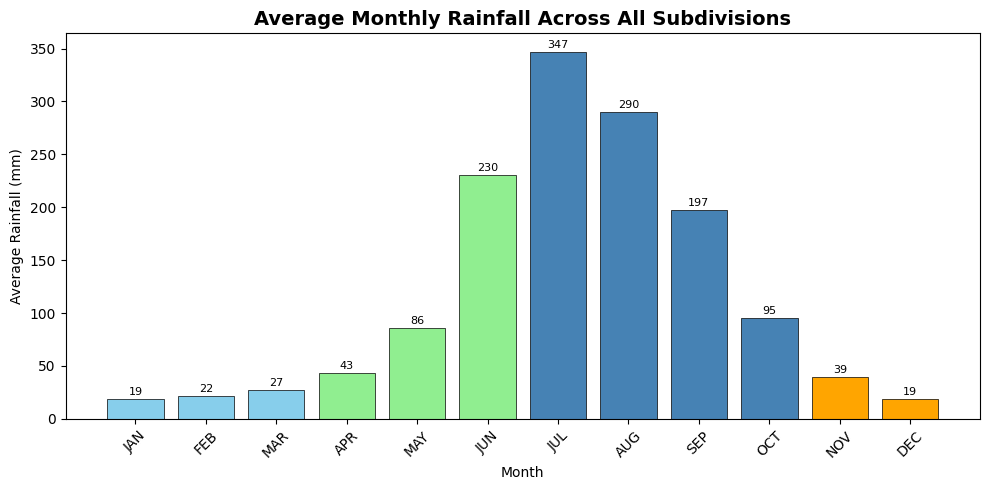

In [21]:
plt.figure(figsize=(10, 5))
month_avg = df[['JAN','FEB','MAR','APR','MAY','JUN',
                'JUL','AUG','SEP','OCT','NOV','DEC']].mean()
colors = ['skyblue']*3 + ['lightgreen']*3 + \
         ['steelblue']*4 + ['orange']*2
bars = plt.bar(month_avg.index, month_avg.values, color=colors, edgecolor='black', linewidth=0.5)
plt.title('Average Monthly Rainfall Across All Subdivisions', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=45)
# Har bar pe value dikhao
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             f'{bar.get_height():.0f}',
             ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('graph2_monthly_bar.png', dpi=150)
plt.show()

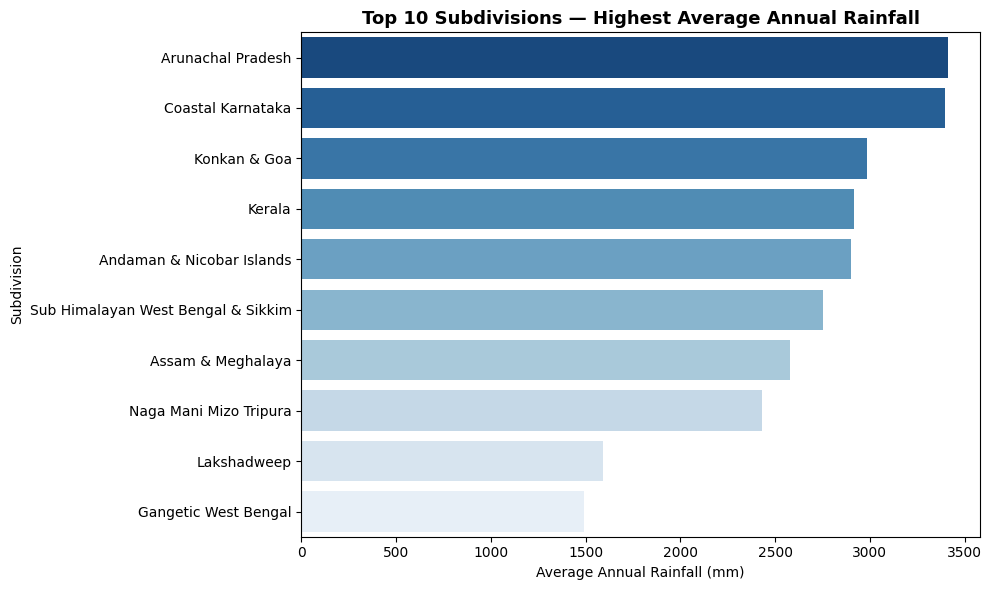

In [22]:
import warnings
warnings.filterwarnings('ignore') 
plt.figure(figsize=(10, 6))
top10 = df.groupby('SUBDIVISION')['ANNUAL'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top10.values, y=top10.index, palette='Blues_r')
plt.title('Top 10 Subdivisions — Highest Average Annual Rainfall', fontsize=13, fontweight='bold')
plt.xlabel('Average Annual Rainfall (mm)')
plt.ylabel('Subdivision')
plt.tight_layout()
plt.savefig('graph3_top10_subdivisions.png', dpi=150)
plt.show()

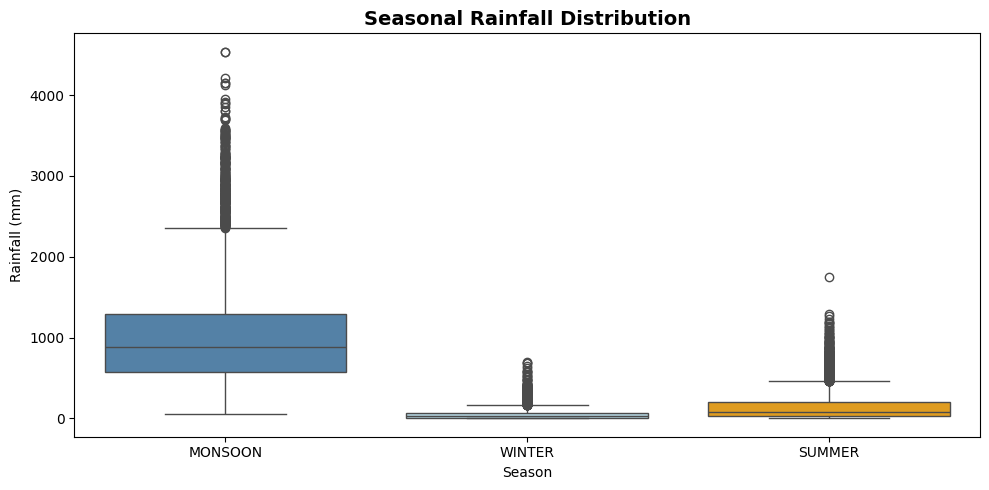

In [23]:
plt.figure(figsize=(10, 5))
season_data = df[['MONSOON','WINTER','SUMMER']].melt(var_name='Season', value_name='Rainfall')
sns.boxplot(x='Season', y='Rainfall', data=season_data,
            palette={'MONSOON':'steelblue','WINTER':'lightblue','SUMMER':'orange'})
plt.title('Seasonal Rainfall Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')
plt.tight_layout()
plt.savefig('graph4_seasonal_boxplot.png', dpi=150)
plt.show()

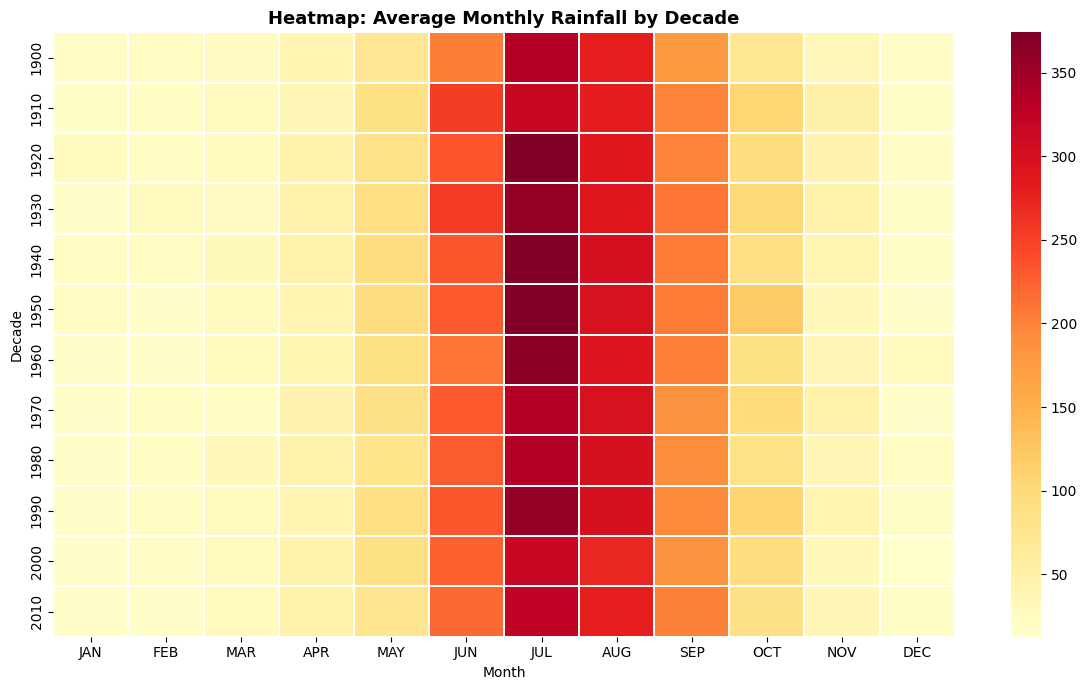

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

df['DECADE'] = (df['YEAR']//10)*10

decade_month = df.groupby('DECADE')[['JAN','FEB','MAR','APR','MAY',
                                     'JUN','JUL','AUG','SEP',
                                     'OCT','NOV','DEC']].mean()

plt.figure(figsize=(12,7))

sns.heatmap(decade_month, cmap='YlOrRd', annot=False,
            linewidths=0.3, fmt='.0f')

plt.title('Heatmap: Average Monthly Rainfall by Decade', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Decade')

plt.tight_layout()
plt.savefig('graph5_heatmap_decade.png', dpi=150)
plt.show()

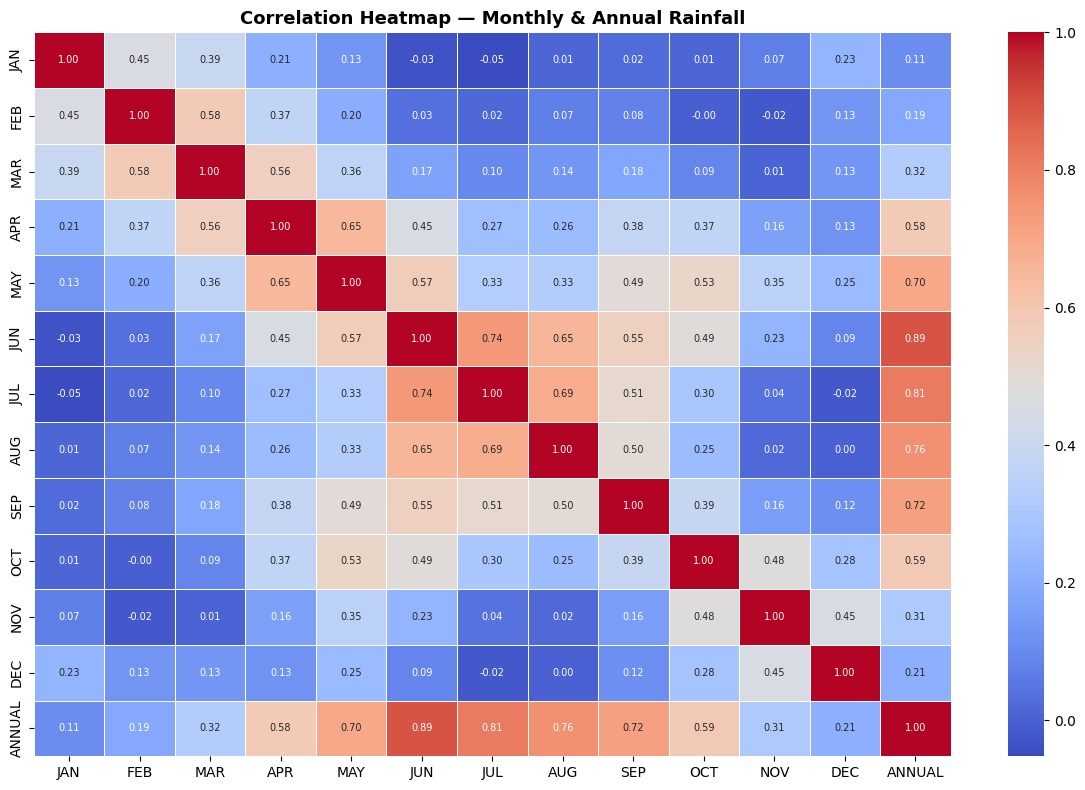

In [25]:
plt.figure(figsize=(12, 8))
corr_cols = ['JAN','FEB','MAR','APR','MAY','JUN',
             'JUL','AUG','SEP','OCT','NOV','DEC','ANNUAL']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 7})
plt.title('Correlation Heatmap — Monthly & Annual Rainfall', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graph6_correlation_heatmap.png', dpi=150)
plt.show()

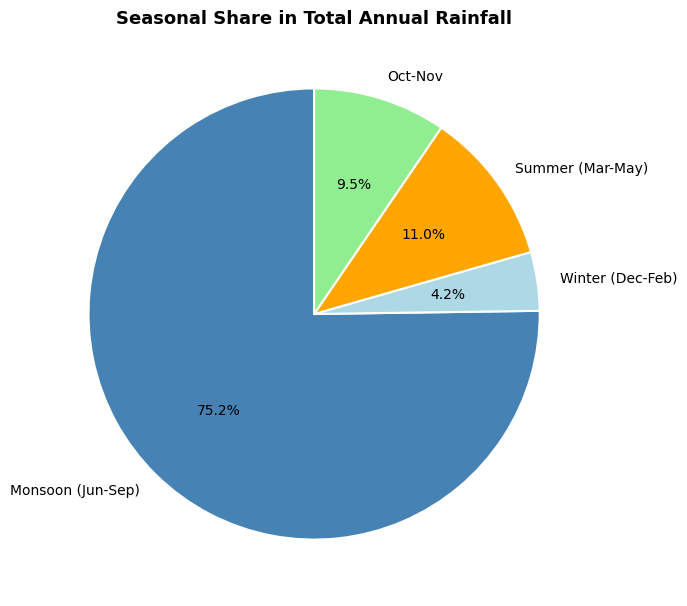

In [26]:
plt.figure(figsize=(7, 7))
season_share = {
    'Monsoon (Jun-Sep)' : df['MONSOON'].mean(),
    'Winter (Dec-Feb)'  : df['WINTER'].mean(),
    'Summer (Mar-May)'  : df['SUMMER'].mean(),
    'Oct-Nov'           : df[['OCT','NOV']].sum(axis=1).mean()
}
plt.pie(season_share.values(),
        labels=season_share.keys(),
        autopct='%1.1f%%',
        colors=['steelblue','lightblue','orange','lightgreen'],
        startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5})
plt.title('Seasonal Share in Total Annual Rainfall', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graph7_pie_season_share.png', dpi=150)
plt.show()

In [27]:
df = df[['YEAR', 'ANNUAL']]

In [28]:
df = df.dropna()

In [29]:
X = df[['YEAR']]   # input
y = df['ANNUAL']  # output

In [30]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
future_years = np.array([[2025], [2030]])

predictions = model.predict(future_years)

for year, rain in zip(future_years, predictions):
    print(f"Year: {year[0]} → Predicted Rainfall: {rain:.2f}")

Year: 2025 → Predicted Rainfall: 1390.71
Year: 2030 → Predicted Rainfall: 1388.88


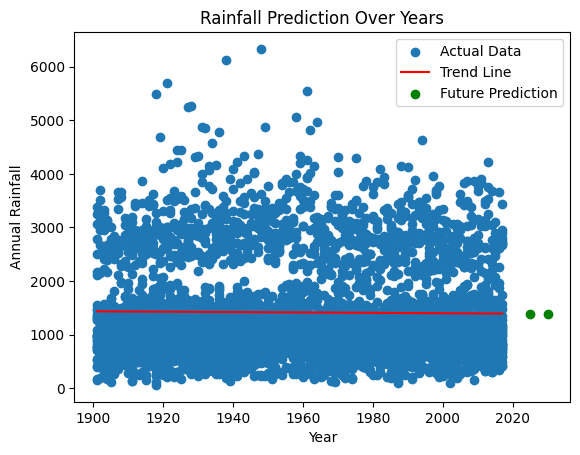

In [32]:
plt.scatter(X, y, label="Actual Data")
plt.plot(X, model.predict(X), color='red', label="Trend Line")

plt.scatter(future_years, predictions, color='green', label="Future Prediction")

plt.xlabel("Year")
plt.ylabel("Annual Rainfall")
plt.title("Rainfall Prediction Over Years")
plt.legend()
plt.show()

In [33]:
import pandas as pd

df_full = pd.read_csv(r"C:\Users\harsh\Downloads\Sub_Division_IMD_2017.csv")

print("Columns in fresh data:\n", df_full.columns)

Columns in fresh data:
 Index(['SUBDIVISION', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JF', 'MAM', 'JJAS',
       'OND'],
      dtype='str')


In [37]:
from sklearn.linear_model import LinearRegression
import pandas as pd

df_full.columns = df_full.columns.str.strip()

months = df_full.columns[2:14]

data = df_full[['YEAR'] + list(months)]

data = data.apply(pd.to_numeric, errors='coerce').dropna()

X = data[['YEAR']]
y = data[months]

model = LinearRegression()
model.fit(X, y)

prediction = model.predict([[2025]])

print("\nMonthly Rainfall Prediction for 2025:\n")

for m, val in zip(months, prediction[0]):
    print(m, ":", round(val, 2))


Monthly Rainfall Prediction for 2025:

JAN : 15.31
FEB : 19.4
MAR : 29.36
APR : 43.89
MAY : 86.49
JUN : 223.96
JUL : 337.54
AUG : 289.57
SEP : 195.72
OCT : 95.4
NOV : 36.14
DEC : 17.86


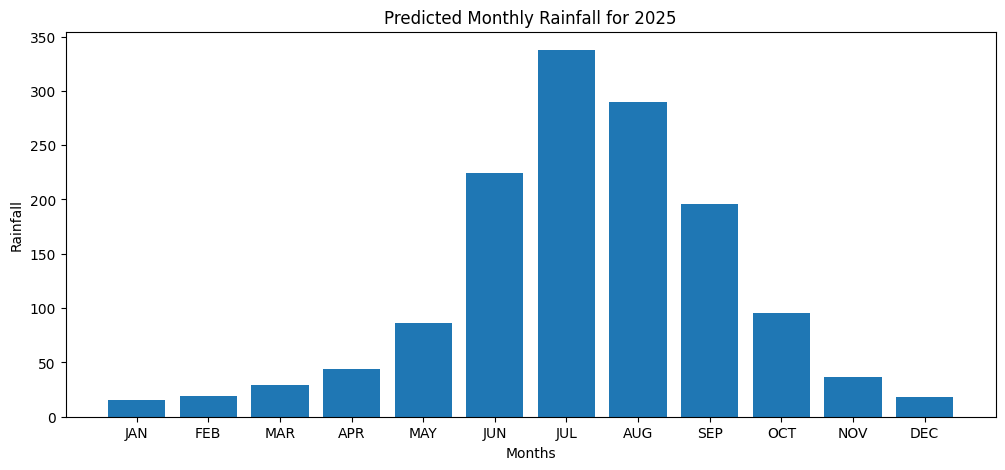

In [38]:
import matplotlib.pyplot as plt
future_year = [[2025]]
prediction = model.predict(future_year)
# Extract values
values = prediction[0]
# Plot graph
plt.figure(figsize=(12,5))
plt.bar(months, values)
plt.xlabel("Months")
plt.ylabel("Rainfall")
plt.title("Predicted Monthly Rainfall for 2025")
plt.savefig("monthly_rainfall_2025.png", dpi=150)
plt.show()